# US Companies Revenue Analysis

## Project Overview

This project analyzes company revenue, employee count, industry,
and revenue growth using data collected from a public webpage.

The data was collected using Python, Requests, and BeautifulSoup.
Pandas was used for data cleaning and analysis, and Matplotlib
was used to create visualizations.

## Project Objectives

- Scrape company data from a public webpage
- Store the data in a Pandas DataFrame
- Clean and prepare the dataset
- Identify the top 10 companies by revenue
- Calculate average revenue
- Analyze companies by industry
- Identify the company with the highest employee count
- Calculate industry-wise average revenue
- Create visualizations using Matplotlib
- Export the cleaned dataset as a CSV file

## Tools & Technologies

- Python
- Requests
- BeautifulSoup
- Pandas
- Matplotlib
- Jupyter Notebook

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## 1. Web Scraping

In [3]:
url='https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue'

headers = {
    'User-Agent': 'yaas'
}
page = requests.get(url,headers=headers)
soup=BeautifulSoup(page.text,'html')

In [6]:
tables=soup.find('table',class_='wikitable sortable')
world_titles=tables.find_all('th')
world_table_title = [title.text.strip() for title in world_titles]
print(world_table_title)

['Rank', 'Name', 'Industry', 'Revenue (USD millions)', 'Revenue growth', 'Employees', 'Headquarters']


In [8]:
df=pd.DataFrame(columns= world_table_title)
df

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters


In [9]:
column_data=tables.find_all('tr')
for row in column_data[1:]:
    row_data= row.find_all('td')
    individual_row_data=[data.text.strip() for data in row_data]
    print(individual_row_data)
    length= len(df)
    df.loc[length]=individual_row_data

['1', 'Walmart', 'Retail', '680,985', '5.1%', '2,100,000', 'Bentonville, Arkansas']
['2', 'Amazon', 'Retail and cloud computing', '637,959', '11.0%', '1,556,000', 'Seattle, Washington']
['3', 'UnitedHealth Group', 'Healthcare', '400,278', '7.7%', '400,000', 'Minnetonka, Minnesota']
['4', 'Apple', 'Technology', '391,035', '2.0%', '164,000', 'Cupertino, California']
['5', 'CVS Health', 'Healthcare', '372,809', '4.2%', '259,500', 'Woonsocket, Rhode Island']
['6', 'Berkshire Hathaway', 'Conglomerate', '371,433', '1.9%', '392,400', 'Omaha, Nebraska']
['7', 'Alphabet', 'Technology and cloud computing', '350,018', '13.9%', '183,323', 'Mountain View, California']
['8', 'Exxon Mobil', 'Petroleum', '349,595', '1.5%', '60,900', 'Spring, Texas']
['9', 'McKesson Corporation', 'Healthcare', '308,951', '11.7%', '48,000', 'Irving, Texas']
['10', 'Cencora', 'Pharmacy wholesale', '293,959', '12.1%', '44,000', 'Conshohocken, Pennsylvania']
['11', 'JPMorgan Chase', 'Financials', '278,906', '16.5%', '317,2

In [12]:
df.head()

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,"680,985",5.1%,"2,100,000","Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,"637,959",11.0%,"1,556,000","Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,"400,278",7.7%,"400,000","Minnetonka, Minnesota"
3,4,Apple,Technology,"391,035",2.0%,"164,000","Cupertino, California"
4,5,CVS Health,Healthcare,"372,809",4.2%,"259,500","Woonsocket, Rhode Island"


In [13]:
df.shape

(100, 7)

In [10]:
df.to_csv(r'D:\programs\projects_for_resume\US_Companies_RowData_webscrape.csv',index=False)

## 2. Data Cleaning

In [11]:
df_clean = df.copy()

In [14]:
df_clean['Revenue (USD millions)'] = (
    df_clean['Revenue (USD millions)']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [15]:
df_clean['Employees'] = (
    df_clean['Employees']
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [16]:
df_clean['Revenue growth'] = (
    df_clean['Revenue growth']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [17]:
df_clean.dtypes

Rank                          str
Name                          str
Industry                      str
Revenue (USD millions)    float64
Revenue growth            float64
Employees                   int64
Headquarters                  str
dtype: object

In [18]:
df_clean.isnull().sum()

Rank                      0
Name                      0
Industry                  0
Revenue (USD millions)    0
Revenue growth            0
Employees                 0
Headquarters              0
dtype: int64

In [19]:
df_clean.describe()

,Revenue (USD millions),Revenue growth,Employees
count,100.00000,100.000000,1.000000e+02
mean,130499.62000,7.689000,1.619777e+05
std,116235.76346,15.258201,2.682762e+05
min,45043.00000,-15.600000,4.200000e+03
25%,56804.75000,0.900000,4.475000e+04
50%,84784.50000,5.050000,8.570000e+04
75%,148911.00000,11.125000,1.886625e+05
max,680985.00000,114.200000,2.100000e+06


## 3. Export Clean Dataset

In [20]:
df_clean.to_csv(r'D:\programs\projects_for_resume\US_Companies_Cleandata_webscrape.csv',index=False)

## 4. Exploratory Data Analysis

1 :— Top 10 companies by revenue

In [21]:
top_10_revenue = (
    df_clean
    .sort_values('Revenue (USD millions)', ascending=False)
    .head(10)
)
top_10_revenue[['Rank', 'Name', 'Revenue (USD millions)']]

,Rank,Name,Revenue (USD millions)
0,1,Walmart,680985.0
1,2,Amazon,637959.0
2,3,UnitedHealth Group,400278.0
3,4,Apple,391035.0
4,5,CVS Health,372809.0
5,6,Berkshire Hathaway,371433.0
6,7,Alphabet,350018.0
7,8,Exxon Mobil,349595.0
8,9,McKesson Corporation,308951.0
9,10,Cencora,293959.0


2 :— Average Revenue

In [22]:
average_revenue = df_clean[
    'Revenue (USD millions)'
].mean()

print(f"Average Revenue: ${average_revenue:,.2f} million")

Average Revenue: $130,499.62 million


3 :— Companies by Industry

In [23]:
companies_by_industry = (
    df_clean['Industry']
    .value_counts()
)

companies_by_industry

Industry
Financials                             16
Retail                                  9
Technology                              9
Petroleum                               9
Healthcare                              7
Insurance                               6
Pharmaceutical                          5
Aerospace and defense                   4
Technology and cloud computing          3
Telecommunications                      3
Food processing                         3
Airline                                 3
Health insurance                        2
Automotive                              2
Beverage                                2
Transportation                          2
Pharmaceutical industry                 2
Retail and cloud computing              1
Conglomerate                            1
Pharmacy wholesale                      1
Conglomerate and telecommunications     1
Automotive and energy                   1
Media                                   1
Food industry            

4 :— Company with Highest Employees

In [26]:
highest_employee_company = df_clean.loc[
    df_clean['Employees'].idxmax()
]

highest_employee_company[
    ['Name', 'Employees']
]

Name         Walmart
Employees    2100000
Name: 0, dtype: object

5 :— Industry-wise Average Revenue

In [27]:
industry_avg_revenue = (
    df_clean.groupby('Industry')['Revenue (USD millions)'].mean().sort_values(ascending=False)
)

industry_avg_revenue

Industry
Retail and cloud computing             637959.000000
Conglomerate                           371433.000000
Pharmacy wholesale                     293959.000000
Healthcare                             245650.000000
Technology and cloud computing         219297.666667
Automotive                             186217.000000
Health insurance                       182441.000000
Retail                                 180898.888889
Petroleum                              134242.777778
Conglomerate and telecommunications    122336.000000
Financials                             117144.687500
Technology                             115737.444444
Telecommunications                     104534.666667
Automotive and energy                   97690.000000
Media                                   91361.000000
Transportation                          89381.500000
Food industry                           85530.000000
Consumer products manufacturing         84039.000000
Pharmaceutical                       

## Charts

1:-Top 10 Companies by Revenue

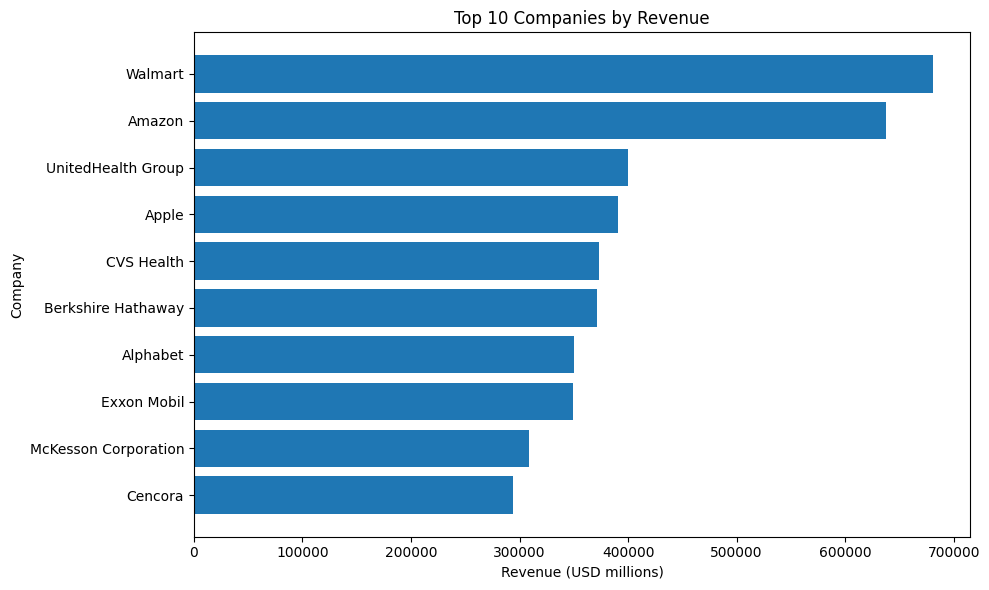

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_revenue['Name'][::-1],
    top_10_revenue['Revenue (USD millions)'][::-1]
)

plt.xlabel('Revenue (USD millions)')
plt.ylabel('Company')
plt.title('Top 10 Companies by Revenue')

plt.tight_layout()
plt.show()

2:-Top 10 Industries by Number of Companies

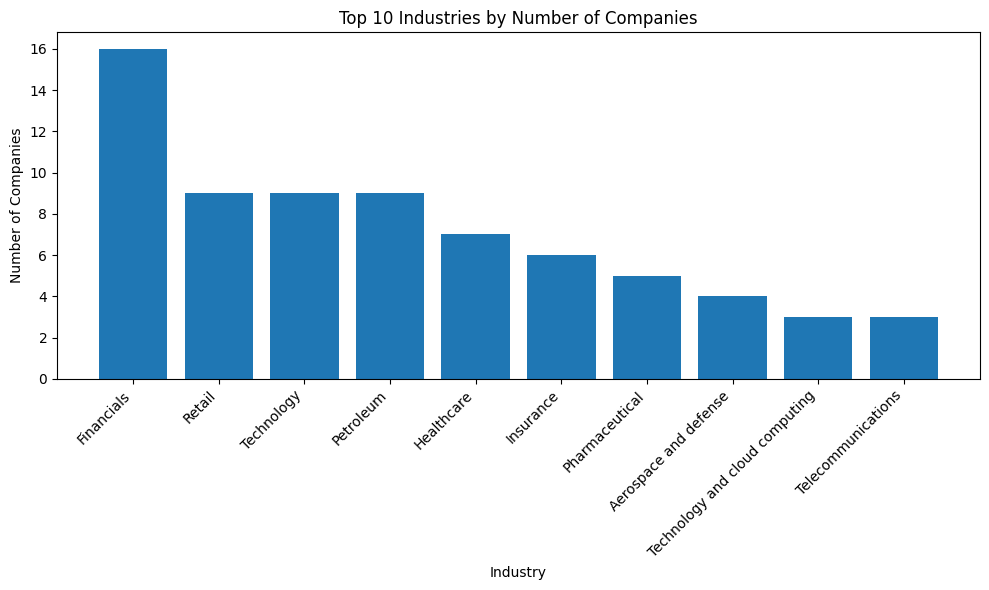

In [29]:
top_10_industries = companies_by_industry.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_industries.index,
    top_10_industries.values
)

plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.title('Top 10 Industries by Number of Companies')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

3:-Top 10 Industries by Average Revenue

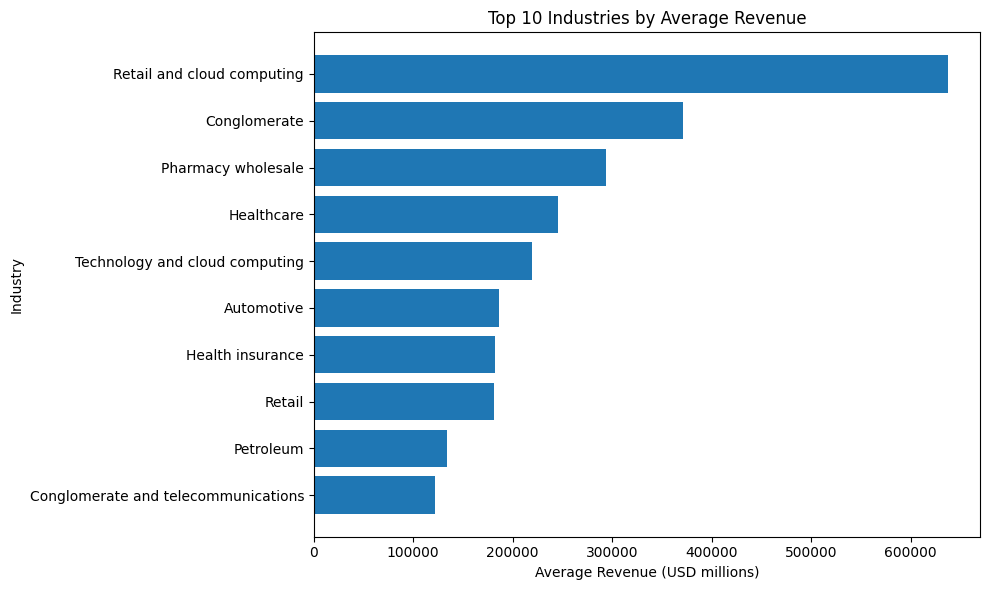

In [30]:
top_10_industry_revenue = industry_avg_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_industry_revenue.index[::-1],
    top_10_industry_revenue.values[::-1]
)

plt.xlabel('Average Revenue (USD millions)')
plt.ylabel('Industry')
plt.title('Top 10 Industries by Average Revenue')

plt.tight_layout()
plt.show()

## Key Findings

- The top companies have much higher revenue than other companies.
- Companies belong to different industries.
- Employee numbers are very different between companies.
- Some industries have higher average revenue than others.
- Industry-wise revenue analysis helps compare business performance.